# Tarefa 2: Regressão (CART × RN MLP)

Este notebook só **chama** os scripts de `src/`, na ordem das etapas do enunciado. Toda a lógica está nos scripts, que também podem ser rodados sozinhos com `uv run python src/<script>.py`. Cada etapa grava os números em `resultados/`, e a etapa seguinte lê de lá.

| Etapa | Script | Saída |
|---|---|---|
| 1. Dataset de treino/validação | `gerar_dataset.py` | `dados/treino_validacao_10000v.csv`, Tabela 1 |
| 2. CART com validação cruzada | `treinar_cart.py` | Tabelas 2 e 3 |
| 3. RN com validação cruzada (~3,5 min) | `treinar_rn.py` | Tabelas 4 e 5 |
| 5–6. Retreino e teste cego | `teste_cego.py` | `modelos/*.joblib`, Tabelas 6, 7 e 8 |
| Relatório e entrega | `gerar_relatorio.py` | `entrega/` |

As decisões de cada etapa estão em `observacoes.md`.

In [1]:
import sys
from pathlib import Path

from IPython.display import IFrame, Image, display

SRC = Path("src").resolve()
sys.path.insert(0, str(SRC))

import validacao_cruzada, gerar_dataset, treinar_cart, treinar_rn, teste_cego, gerar_relatorio

## Validação cruzada: conferência com o exemplo do enunciado

O módulo comum `validacao_cruzada.py` calcula o MSE por fold, a média, o dpa (divisor k−1, ADR 0001) e a média das difs. Antes de usá-lo, confere que reproduz o exemplo do CART U do enunciado (k=3).

In [2]:
validacao_cruzada.main()

Treino    MSE por fold: [0.023200, 0.001100, 0.019800] média=0.014700 dpa=0.011900
Validação MSE por fold: [0.072100, 0.070300, 0.069900] média=0.070767 dpa=0.001172
Diferença absoluta MSE: [0.048900, 0.069200, 0.050100] média=0.056067 dpa=0.011390
treino     média=0.01470 dpa=0.01190  (enunciado: 0.0147 (0.0119))
validacao  média=0.07077 dpa=0.00117  (enunciado: 0.0707 (0.0011))
diferenca  média=0.05607 dpa=0.01139  (enunciado: 0.0560 (0.01139))
Exemplo do enunciado reproduzido.


## 1) Dataset de treino/validação (Tabela 1)

Gera as 10.000 vítimas com o `gerar_dados_vitimas.py` do VictSim3 (em `vendor/victsim3/`, sem modificação): 2.500 por classe de tri antes do ruído, idade média 40 e desvio 25, ruído 0,05, semente 42.

In [3]:
gerar_dataset.main()


Dataset salvo com sucesso em: /home/taronky/Desktop/scalcon/sis int/trabalho_2/SI-T02-Regressao/dados/treino_validacao_10000v.csv

Distribuição final de vítimas por classificação START (após ruído):
  0 (Verde): 2448 (24.5%)
  1 (Amarelo): 2567 (25.7%)
  2 (Vermelho): 2561 (25.6%)
  3 (Preto): 2424 (24.2%)
total de vítimas: 10000

Tabela 1 salva em: resultados/tabela1_dataset.json
{
  "vitimas_por_classe": {
    "verde": 2448,
    "amarelo": 2567,
    "vermelho": 2561,
    "preto": 2424
  },
  "idade_media": 39.9198,
  "dpa_idade": 23.201564585603318,
  "ruido": 0.05
}


## 2) CART: hiperparametrizações U, E e O (Tabelas 2 e 3)

Validação cruzada com k=5 (`KFold` embaralhado, semente 42), os mesmos folds para o CART e a RN.

In [4]:
treinar_cart.main()


U: DecisionTreeRegressor(max_depth=2, min_samples_leaf=0.25, random_state=42)
Treino    MSE por fold: [0.009379, 0.009439, 0.009485, 0.009468, 0.009541] média=0.009462 dpa=0.000059
Validação MSE por fold: [0.009802, 0.009561, 0.009378, 0.009446, 0.009155] média=0.009468 dpa=0.000238
Diferença absoluta MSE: [0.000423, 0.000122, 0.000107, 0.000022, 0.000386] média=0.000212 dpa=0.000180



E: DecisionTreeRegressor(max_depth=10, min_samples_leaf=20, random_state=42)
Treino    MSE por fold: [0.001961, 0.001974, 0.001978, 0.001979, 0.001949] média=0.001968 dpa=0.000013
Validação MSE por fold: [0.002690, 0.002564, 0.002658, 0.002560, 0.002596] média=0.002614 dpa=0.000058
Diferença absoluta MSE: [0.000729, 0.000590, 0.000680, 0.000581, 0.000647] média=0.000646 dpa=0.000062



O: DecisionTreeRegressor(random_state=42)
Treino    MSE por fold: [0.000000, 0.000000, 0.000000, 0.000000, 0.000000] média=0.000000 dpa=0.000000
Validação MSE por fold: [0.004187, 0.004141, 0.004142, 0.003867, 0.003995] média=0.004066 dpa=0.000133
Diferença absoluta MSE: [0.004187, 0.004141, 0.004142, 0.003867, 0.003995] média=0.004066 dpa=0.000133

Tabela 2: hiperparametrizações CART
MODELO                  U                       E                       O                       
Min_samples_leaf        0.25                    20                      1                       
Max_depth               2                       10                      None                    
Random_state            42                      42                      42                      

Tabela 3: resultados dos modelos CART
MODELO                  U                       E                       O                       
TREINO MSE (dpa)        0,009462 (0,000059)     0,001968 (0,000013)     0,000000 (0,000

## 3) RN MLP: hiperparametrizações U, E e O (Tabelas 4 e 5)

`StandardScaler` + `MLPRegressor` num Pipeline, para que a padronização seja ajustada só no treino de cada fold. Leva ~3,5 min, quase todo na O.

In [5]:
treinar_rn.main()


U: {'solver': 'sgd', 'activation': 'tanh', 'momentum': 0.95, 'learning_rate': 'constant', 'shuffle': True, 'random_state': 42, 'hidden_layer_sizes': (2,), 'learning_rate_init': 0.001, 'alpha': 1.0, 'batch_size': 'auto', 'max_iter': 200, 'tol': 0.0001, 'n_iter_no_change': 10}
1.7 s; épocas por fold [67, 67, 67, 67, 67]; 0/5 folds em max_iter
Treino    MSE por fold: [0.007472, 0.007371, 0.007314, 0.007358, 0.007451] média=0.007393 dpa=0.000066
Validação MSE por fold: [0.007181, 0.007337, 0.007574, 0.007774, 0.007175] média=0.007408 dpa=0.000261
Diferença absoluta MSE: [0.000291, 0.000033, 0.000260, 0.000416, 0.000276] média=0.000255 dpa=0.000139



E: {'solver': 'sgd', 'activation': 'tanh', 'momentum': 0.95, 'learning_rate': 'constant', 'shuffle': True, 'random_state': 42, 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.02, 'alpha': 0.01, 'batch_size': 'auto', 'max_iter': 2000, 'tol': 1e-06, 'n_iter_no_change': 20}
22.5 s; épocas por fold [1193, 1477, 1149, 1383, 1437]; 0/5 folds em max_iter
Treino    MSE por fold: [0.001624, 0.001625, 0.001628, 0.001633, 0.001636] média=0.001629 dpa=0.000005
Validação MSE por fold: [0.001692, 0.001699, 0.001703, 0.001646, 0.001659] média=0.001680 dpa=0.000026
Diferença absoluta MSE: [0.000068, 0.000074, 0.000075, 0.000013, 0.000023] média=0.000051 dpa=0.000030


/home/taronky/Desktop/scalcon/sis int/trabalho_2/SI-T02-Regressao/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(


/home/taronky/Desktop/scalcon/sis int/trabalho_2/SI-T02-Regressao/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(


/home/taronky/Desktop/scalcon/sis int/trabalho_2/SI-T02-Regressao/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(


/home/taronky/Desktop/scalcon/sis int/trabalho_2/SI-T02-Regressao/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(



O: {'solver': 'sgd', 'activation': 'tanh', 'momentum': 0.95, 'learning_rate': 'constant', 'shuffle': True, 'random_state': 42, 'hidden_layer_sizes': (64, 64, 64, 64, 64, 64, 64, 64, 64, 64), 'learning_rate_init': 0.05, 'alpha': 0.0, 'batch_size': 16, 'max_iter': 400, 'tol': 0.0001, 'n_iter_no_change': 400}
177.3 s; épocas por fold [400, 400, 400, 400, 400]; 5/5 folds em max_iter
Treino    MSE por fold: [0.001294, 0.001358, 0.001395, 0.001334, 0.001369] média=0.001350 dpa=0.000038
Validação MSE por fold: [0.001941, 0.001940, 0.001916, 0.001953, 0.001824] média=0.001915 dpa=0.000052
Diferença absoluta MSE: [0.000647, 0.000582, 0.000521, 0.000619, 0.000455] média=0.000565 dpa=0.000077

Tabela 4: hiperparametrizações RN
MODELO                  U                                 E                                 O                                 
Topologia               [2]                               [64 32]                           [64 64 64 64 64 64 64 64 64 64]   
Função de ativação 

/home/taronky/Desktop/scalcon/sis int/trabalho_2/SI-T02-Regressao/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(


## 5–6) Retreino e teste cego (Tabelas 6, 7 e 8)

Retreina o melhor CART e a melhor RN com as 10.000 vítimas, salva `melhor_cart.joblib`, `scaler.joblib` e `melhor_rn.joblib` em `modelos/` e só então lê o dataset de teste cego (1.300 vítimas), pela primeira e única vez.

In [6]:
teste_cego.main()

Melhor CART (E) retreinado: {'tempo_s': 0.0178587400005199, 'profundidade': 10, 'folhas': 272, 'mse_treino': 0.0019570530564405855}
Melhor RN (E) retreinada: {'tempo_s': 18.22739306999938, 'epocas': 1357, 'max_iter': 2000, 'mse_treino': 0.0016393581221839035}
Modelos salvos em: modelos/melhor_cart.joblib, modelos/scaler.joblib, modelos/melhor_rn.joblib



Tabela 6: melhor CART x melhor RN
                        Melhor CART (E)             Melhor RN (E)               
TREINO MSE (dpa)        0,001968 (0,000013)         0,001629 (0,000005)         
VALIDAÇÃO MSE (dpa)     0,002614 (0,000058)         0,001680 (0,000026)         
MÉDIA DAS DIFS. (dpa)   0,000646 (0,000062)         0,000051 (0,000030)         

Tabela 7: teste cego, melhor CART x melhor RN
                        Melhor CART (E)             Melhor RN (E)               
MSE                     0,002677                    0,001694                    
RMSE                    0,051744                    0,041161                    
Melhor no teste cego: RN; ganho % de MSE 36,72, de RMSE 20,45

Gráficos de dispersão (Tabela 8): resultados/dispersao_cart.png, resultados/dispersao_rn.png
Tabelas 6, 7 e 8 salvas em: resultados/tabelas6_7_8_teste_cego.json


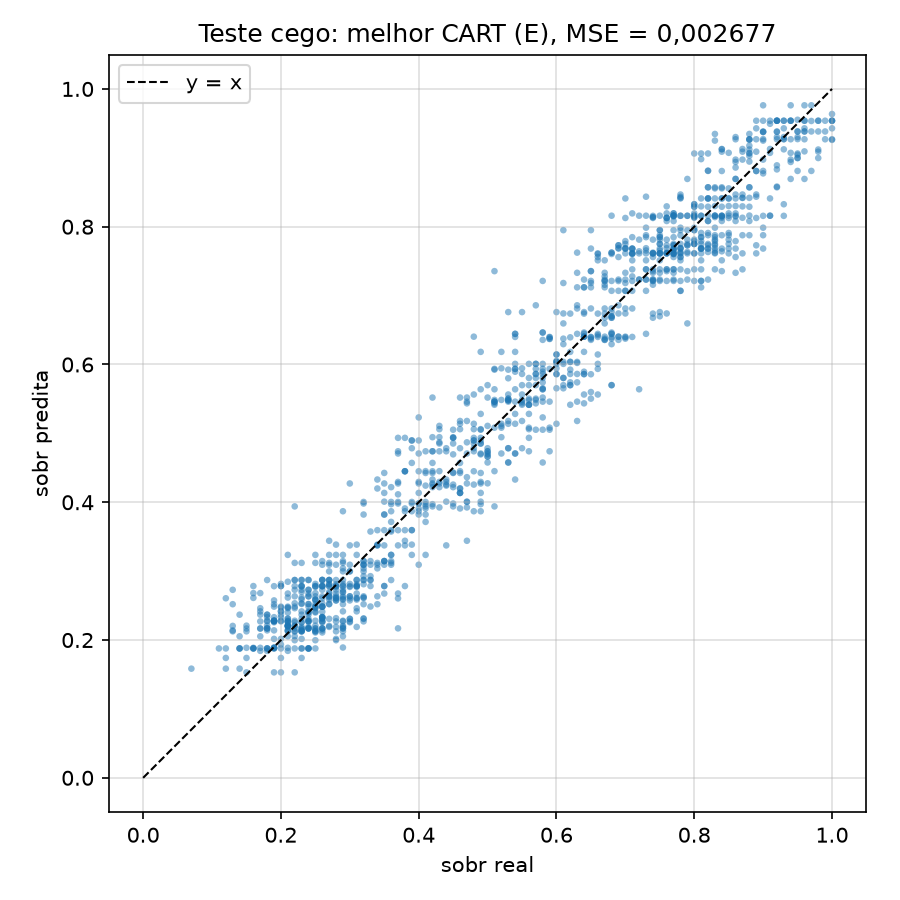

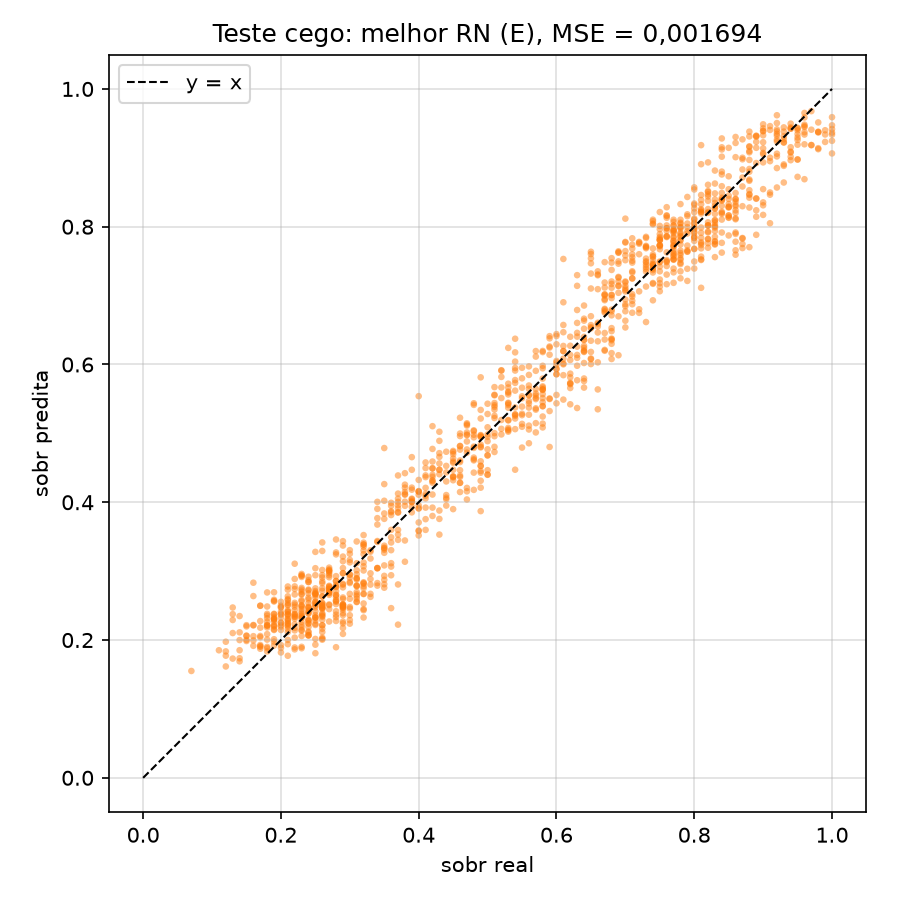

In [7]:
for grafico in ("dispersao_cart.png", "dispersao_rn.png"):
    display(Image(filename=f"resultados/{grafico}", width=450))

## Relatório PDF e pacote de entrega

Gera `entrega/relatorio_T02.pdf` (só as tabelas e os gráficos do enunciado) e copia para `entrega/` os `.joblib` e o zip do código-fonte, os arquivos que vão para o Moodle.

In [8]:
gerar_relatorio.main()
IFrame("entrega/relatorio_T02.pdf", width=800, height=600)

Pacote de entrega em entrega/:
  codigo_fonte_T02.zip       103060 bytes
  melhor_cart.joblib          40577 bytes
  melhor_rn.joblib           100927 bytes
  relatorio_T02.pdf          285721 bytes
  scaler.joblib                1127 bytes

codigo_fonte_T02.zip (11 arquivos):
  codigo_fonte_T02/src/gerar_dataset.py
  codigo_fonte_T02/src/gerar_relatorio.py
  codigo_fonte_T02/src/relatorio/relatorio.typ
  codigo_fonte_T02/src/teste_cego.py
  codigo_fonte_T02/src/treinar_cart.py
  codigo_fonte_T02/src/treinar_rn.py
  codigo_fonte_T02/src/validacao_cruzada.py
  codigo_fonte_T02/vendor/victsim3/gerar_dados_vitimas.py
  codigo_fonte_T02/pyproject.toml
  codigo_fonte_T02/uv.lock
  codigo_fonte_T02/.python-version
